In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

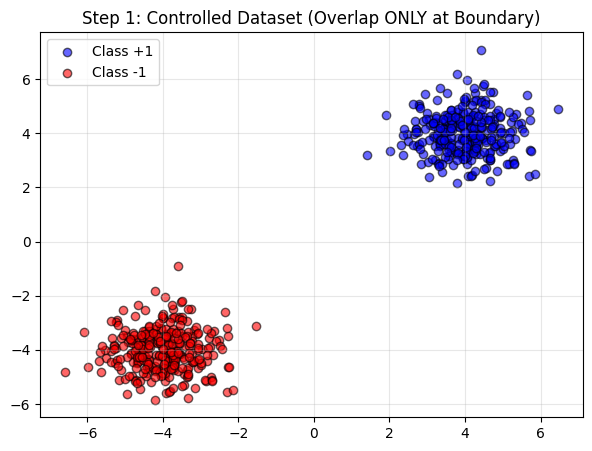

In [2]:
# Population A: The "Very Easy" Points (Far away, tight clusters)
X_easy_neg, y_easy_neg = make_blobs(n_samples=300, centers=[[-4, -4]], cluster_std=0.8, random_state=42)
y_easy_neg = np.full(300, -1)
# Population B: The "Very Easy" Points (Far Right/Top)
X_easy_pos, y_easy_pos = make_blobs(n_samples=300, centers=[[4, 4]], cluster_std=0.8, random_state=42)
y_easy_pos = np.full(300, 1)

# Population C: The "Hard" Boundary Points (Dead Center)
# X_hard_neg, _ = make_blobs(n_samples=50, centers=[[-0.5, 0.5]], cluster_std=0.5, random_state=42)
# y_hard_neg = np.full(50, -1)
# X_hard_pos, _ = make_blobs(n_samples=50, centers=[[0.5, -0.5]], cluster_std=0.5, random_state=42)
# y_hard_pos = np.full(50, 1)

# Combine them all together
# X = np.vstack((X_easy_neg, X_easy_pos, X_hard_neg, X_hard_pos))
# y = np.concatenate((y_easy_neg, y_easy_pos, y_hard_neg, y_hard_pos))
X = np.vstack((X_easy_neg, X_easy_pos))
y = np.concatenate((y_easy_neg, y_easy_pos))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='blue', label='Class +1', alpha=0.6, edgecolors='k')
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], c='red', label='Class -1', alpha=0.6, edgecolors='k')
plt.title("Step 1: Controlled Dataset (Overlap ONLY at Boundary)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

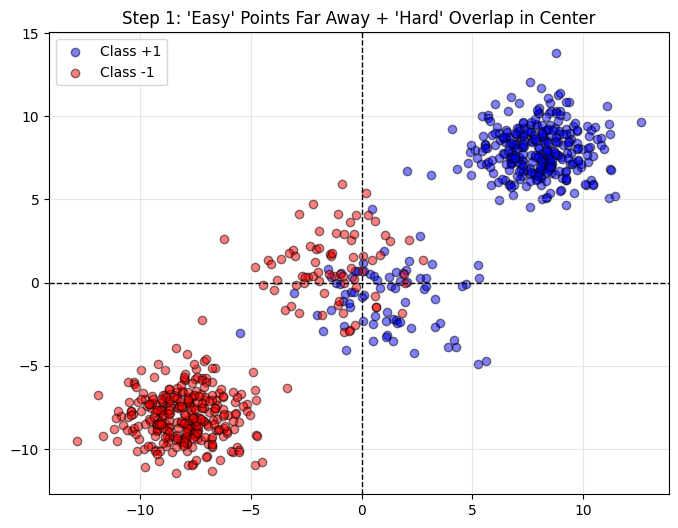

In [3]:
# Population A: The "Very Easy" Points (Far Left/Bottom)
X_easy_neg, y_easy_neg = make_blobs(n_samples=300, centers=[[-8, -8]], cluster_std=1.5, random_state=42)
y_easy_neg = np.full(300, -1) # All definitely Class -1

# Population B: The "Very Easy" Points (Far Right/Top)
X_easy_pos, y_easy_pos = make_blobs(n_samples=300, centers=[[8, 8]], cluster_std=1.5, random_state=42)
y_easy_pos = np.full(300, 1) # All definitely Class +1

# Population C: The "Hard" Boundary Points (Dead Center)
# This creates the overlapping "danger zone" that causes the model to thrash.
X_hard, y_hard_raw = make_blobs(n_samples=150, centers=[[-1, 1], [1, -1]], cluster_std=2.0, random_state=42)
y_hard = np.where(y_hard_raw == 0, -1, 1)

# Combine them all together
X = np.vstack((X_easy_neg, X_easy_pos, X_hard))
y = np.concatenate((y_easy_neg, y_easy_pos, y_hard))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='blue', label='Class +1', alpha=0.5, edgecolors='k')
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], c='red', label='Class -1', alpha=0.5, edgecolors='k')
plt.title("Step 1: 'Easy' Points Far Away + 'Hard' Overlap in Center")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.show()

In [5]:
T = 20
m_train = X_train.shape[0]

k = 0
V = [np.zeros(X_train.shape[1])]
C = [0]

for epoch in range(T):
    for i in range(m_train):
        x_i = X_train[i]
        y_i = y_train[i]

        dot_product = np.dot(V[k], x_i)
        y_hat = 1 if dot_product >= 0 else -1

        if y_hat == y_i:
            C[k] += 1
        else:
            V.append(V[k] + y_i * x_i)
            C.append(1)
            k += 1

total_c = sum(C)

In [6]:
m_test = X_test.shape[0]
final_predictions = np.zeros(m_test)
confidences = np.zeros(m_test)

for i in range(m_test):
    x_i = X_test[i]
    s = 0

    # The committee (V and C) was built on training data,
    # but now votes on the unseen test data.
    for j in range(k + 1):
        vote = 1 if np.dot(V[j], x_i) >= 0 else -1
        s += C[j] * vote

    final_predictions[i] = 1 if s >= 0 else -1
    confidences[i] = abs(s) / total_c
    #try confidence = |#+ - #-|

is_correct = (final_predictions == y_test)

[0.         0.02040816 0.04081633 0.06122449 0.08163265 0.10204082
 0.12244898 0.14285714 0.16326531 0.18367347 0.20408163 0.2244898
 0.24489796 0.26530612 0.28571429 0.30612245 0.32653061 0.34693878
 0.36734694 0.3877551  0.40816327 0.42857143 0.44897959 0.46938776
 0.48979592 0.51020408 0.53061224 0.55102041 0.57142857 0.59183673
 0.6122449  0.63265306 0.65306122 0.67346939 0.69387755 0.71428571
 0.73469388 0.75510204 0.7755102  0.79591837 0.81632653 0.83673469
 0.85714286 0.87755102 0.89795918 0.91836735 0.93877551 0.95918367
 0.97959184 1.        ]


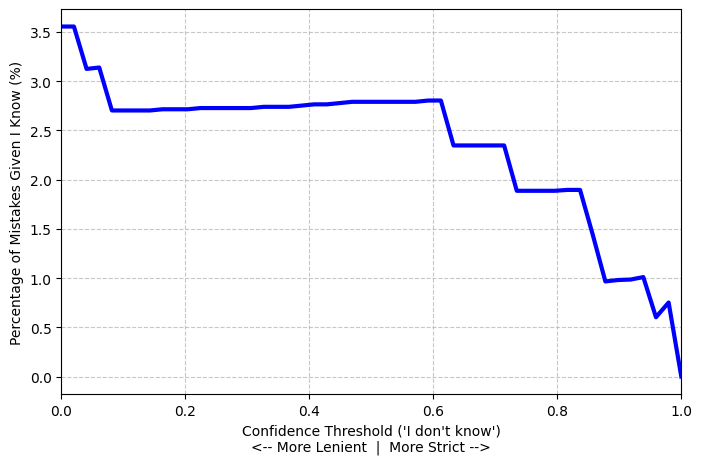

In [7]:
thresholds = np.linspace(0, 1.0, 50)
error_rates = []
print(thresholds)
for t in thresholds:
    # "I don't know" logic: Reject any example where confidence < threshold
    accepted_mask = confidences >= t
    total_accepted = np.sum(accepted_mask)

    if total_accepted == 0:
        error_rates.append(0)
    else:
        errors_on_accepted = np.sum(~is_correct[accepted_mask])
        error_rate = (errors_on_accepted / total_accepted) * 100
        error_rates.append(error_rate)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, error_rates, 'b-', lw=3)
plt.xlabel("Confidence Threshold ('I don't know')\n<-- More Lenient  |  More Strict -->")
plt.ylabel("Percentage of Mistakes Given I Know (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1)
plt.show()